# Assignment 08: Classification Models Comparison
### This is based on Module 06 we have learnt in the class: Logistic Regression | SVM | Naive Bayes | Decision Tree

**Dataset:** disease_risk_dataset.csv (400 patient records)
**Target:** disease_risk (0 = Low Risk, 1 = High Risk)



### What we are doing in this notebook is

| Part | Content |
|------|---------|
| **A** | Exploratory Data Analysis: structure, missing values, class balance, feature/target relationships |
| **B** | Preprocessing: imputation, train/test split, feature scaling |
| **C** | Training Logistic Regression, SVM (linear + RBF), Gaussian Naive Bayes, Decision Tree, defaults then tuned |
| **D** | Evaluation: Accuracy, Precision, Recall, F1, confusion matrices, ROC curves, summary table |
| **E** | Analysis & conclusion |
| **Bonus** | KNN as a 5th model, 5-fold cross-validation (mean ± std), Decision Tree feature importance, decision-threshold analysis |

Every modelling step uses `random_state=42` so the notebook reproduces exactly on re-run.

## Setup


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GridSearchCV,
                                     cross_val_score, StratifiedKFold)
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve,
                             classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"

print("Libraries loaded. Random state fixed at", RANDOM_STATE)

Libraries loaded. Random state fixed at 42


# Part 1: Exploratory Data Analysis

## 1.1 Load the dataset and inspect its structure

The loader accepts either the .csv or the .tsv version of the file so the notebook runs wherever the data happens to sit.

In [ ]:
import os

CANDIDATES = [
    "disease_risk_dataset - disease_risk_dataset.tsv",
    "disease_risk_dataset.csv",
]

path = next((p for p in CANDIDATES if os.path.exists(p)), None)
if path is None:
    raise FileNotFoundError(
        "Put disease_risk_dataset.csv next to this notebook. Looked for: " + ", ".join(CANDIDATES)
    )

sep = "\t" if path.endswith(".tsv") else ","
df = pd.read_csv(path, sep=sep)

print(f"Loaded: {path}")
print(f"Shape : {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded: disease_risk_dataset - disease_risk_dataset.tsv
Shape : 400 rows x 11 columns


,age,sex,bmi,blood_pressure,cholesterol,blood_sugar,max_heart_rate,exercise_angina,smoking,family_history,disease_risk
0,58,0,29.9,107,239.0,87.0,155,1,1,1,1
1,71,0,29.3,134,235.0,119.0,185,1,1,0,1
2,48,0,22.5,122,262.0,53.0,143,0,1,0,0
3,34,1,26.0,140,200.0,104.0,156,0,0,0,0
4,62,0,15.5,132,215.0,NaN,137,1,1,1,0


In [3]:
print("=" * 60)
print("DATAFRAME INFO")
print("=" * 60)
df.info()

DATAFRAME INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   age              400 non-null    int64  
 1   sex              400 non-null    int64  
 2   bmi              392 non-null    float64
 3   blood_pressure   400 non-null    int64  
 4   cholesterol      392 non-null    float64
 5   blood_sugar      392 non-null    float64
 6   max_heart_rate   400 non-null    int64  
 7   exercise_angina  400 non-null    int64  
 8   smoking          400 non-null    int64  
 9   family_history   400 non-null    int64  
 10  disease_risk     400 non-null    int64  
dtypes: float64(3), int64(8)
memory usage: 34.5 KB


In [4]:
print("=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)
df.describe().T.round(2)

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,400.0,49.88,17.70,20.0,35.00,51.0,64.25,79.0
sex,400.0,0.51,0.50,0.0,0.00,1.0,1.00,1.0
bmi,392.0,26.00,5.13,15.0,22.70,26.0,29.70,39.9
blood_pressure,400.0,125.10,17.39,62.0,113.00,126.0,136.00,178.0
cholesterol,392.0,209.09,40.20,94.0,180.75,210.5,237.00,309.0
blood_sugar,392.0,99.27,24.92,28.0,82.75,100.0,116.00,168.0
max_heart_rate,400.0,149.36,19.61,81.0,136.00,150.0,163.00,204.0
exercise_angina,400.0,0.50,0.50,0.0,0.00,0.0,1.00,1.0
smoking,400.0,0.49,0.50,0.0,0.00,0.0,1.00,1.0
family_history,400.0,0.51,0.50,0.0,0.00,1.0,1.00,1.0


**Reading the output above**

- 400 rows 11 columns, no duplicated or ID-like columns to drop.
- Six columns are genuinely continuous `age`, `bmi`, `blood_pressure`, `cholesterol`, `blood_sugar`, `max_heart_rate` out of which four are already binary 0/1 such as `sex`, `exercise_angina`, `smoking`, `family_history`, so no categorical encoding is needed, since they are effectively pre encoded dummy variables.
- The `count` row of `describe()` shows 392 instead of 400 for three columns, which is the first sign of missing data.

## 1.2 Missing values

In [5]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "dtype": df.dtypes.astype(str),
})
missing = missing[missing.missing_count > 0].sort_values("missing_count", ascending=False)

print("Columns containing missing values:\n")
print(missing.to_string() if len(missing) else "None")
print(f"\nTotal missing cells        : {int(df.isna().sum().sum())}")
print(f"Rows with >=1 missing value: {int(df.isna().any(axis=1).sum())} of {len(df)}")

Columns containing missing values:

             missing_count  missing_pct    dtype
bmi                      8          2.0  float64
cholesterol              8          2.0  float64
blood_sugar              8          2.0  float64

Total missing cells        : 24
Rows with >=1 missing value: 24 of 400


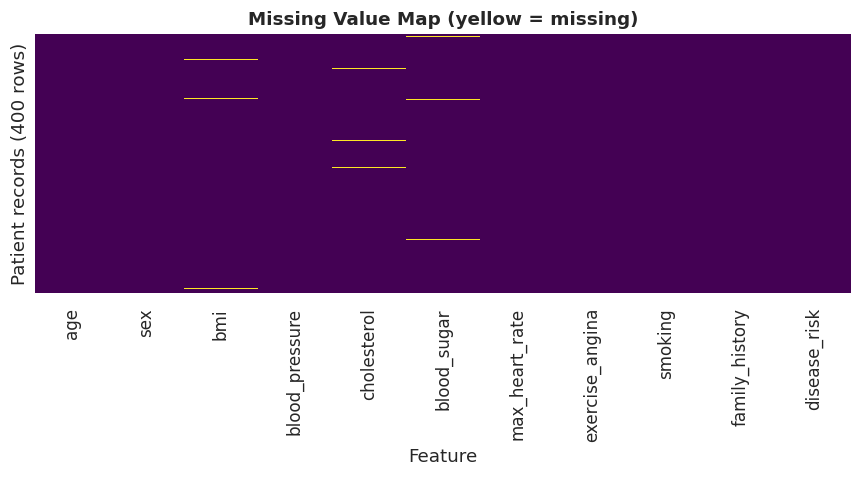

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(df.isna(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
ax.set_title("Missing Value Map (yellow = missing)")
ax.set_xlabel("Feature")
ax.set_ylabel("Patient records (400 rows)")
plt.tight_layout()
plt.show()

**Finding:** There are exactly three columns that are affected such as `bmi`, `cholesterol` and `blood_sugar` with 8 missing values each. The map shows the gaps are scattered rather than clustered in particular rows, which is consistent with values missing at random rather than a systematic collection failure. At 2%, dropping rows would throw away usable patients for no good
reason.

## 1.3 Class distribution of the target

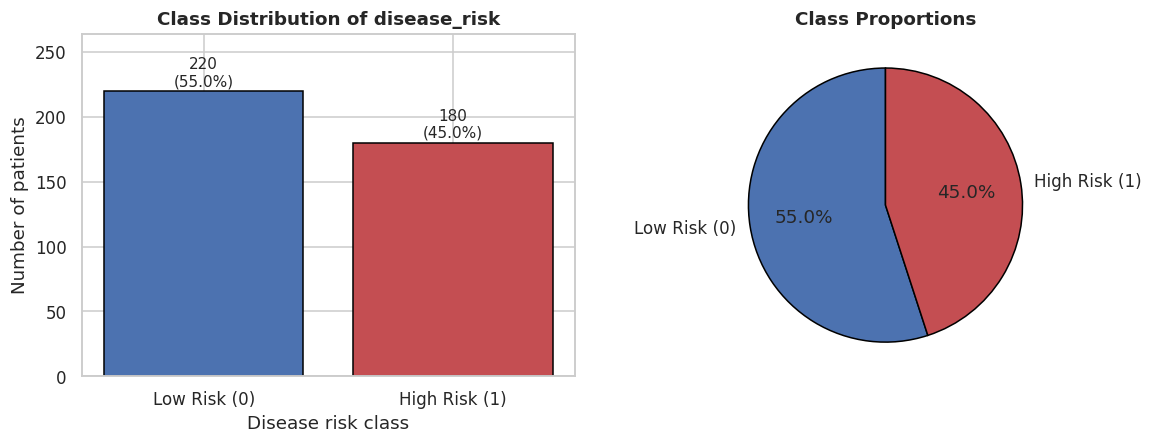

Low Risk  : 220 (55.0%)
High Risk : 180 (45.0%)
Imbalance ratio: 1.22 : 1


In [7]:
counts = df["disease_risk"].value_counts().sort_index()
pcts = df["disease_risk"].value_counts(normalize=True).sort_index() * 100
labels = ["Low Risk (0)", "High Risk (1)"]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

bars = axes[0].bar(labels, counts.values, color=["#4C72B0", "#C44E52"], edgecolor="black")
axes[0].set_title("Class Distribution of disease_risk")
axes[0].set_xlabel("Disease risk class")
axes[0].set_ylabel("Number of patients")
for b, v, p in zip(bars, counts.values, pcts.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 4, f"{v}\n({p:.1f}%)",
                 ha="center", fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.2)

axes[1].pie(counts.values, labels=labels, autopct="%1.1f%%", startangle=90,
            colors=["#4C72B0", "#C44E52"], wedgeprops={"edgecolor": "black"})
axes[1].set_title("Class Proportions")

plt.tight_layout()
plt.show()

print(f"Low Risk  : {counts[0]} ({pcts[0]:.1f}%)")
print(f"High Risk : {counts[1]} ({pcts[1]:.1f}%)")
print(f"Imbalance ratio: {counts[0] / counts[1]:.2f} : 1")

I have found around 220 low risk vs 180 high risk patients with a 55/45 split. This is mildly imbalanced but not problematic so no resampling is required in this case. The practical consequence is that a useless model that always predicts `Low Risk` would already score **55% accuracy** so 55% is the baseline for any model that must clearly beat it. This is exactly why accuracy alone is a poor assesment here and why Part 4 reports precision, recall, F1 and ROC AUC alongside it.

## 1.4 Feature and target relationships

Three views such as continuous features by class boxplots binary features by class risk rates and a correlation heatmap.

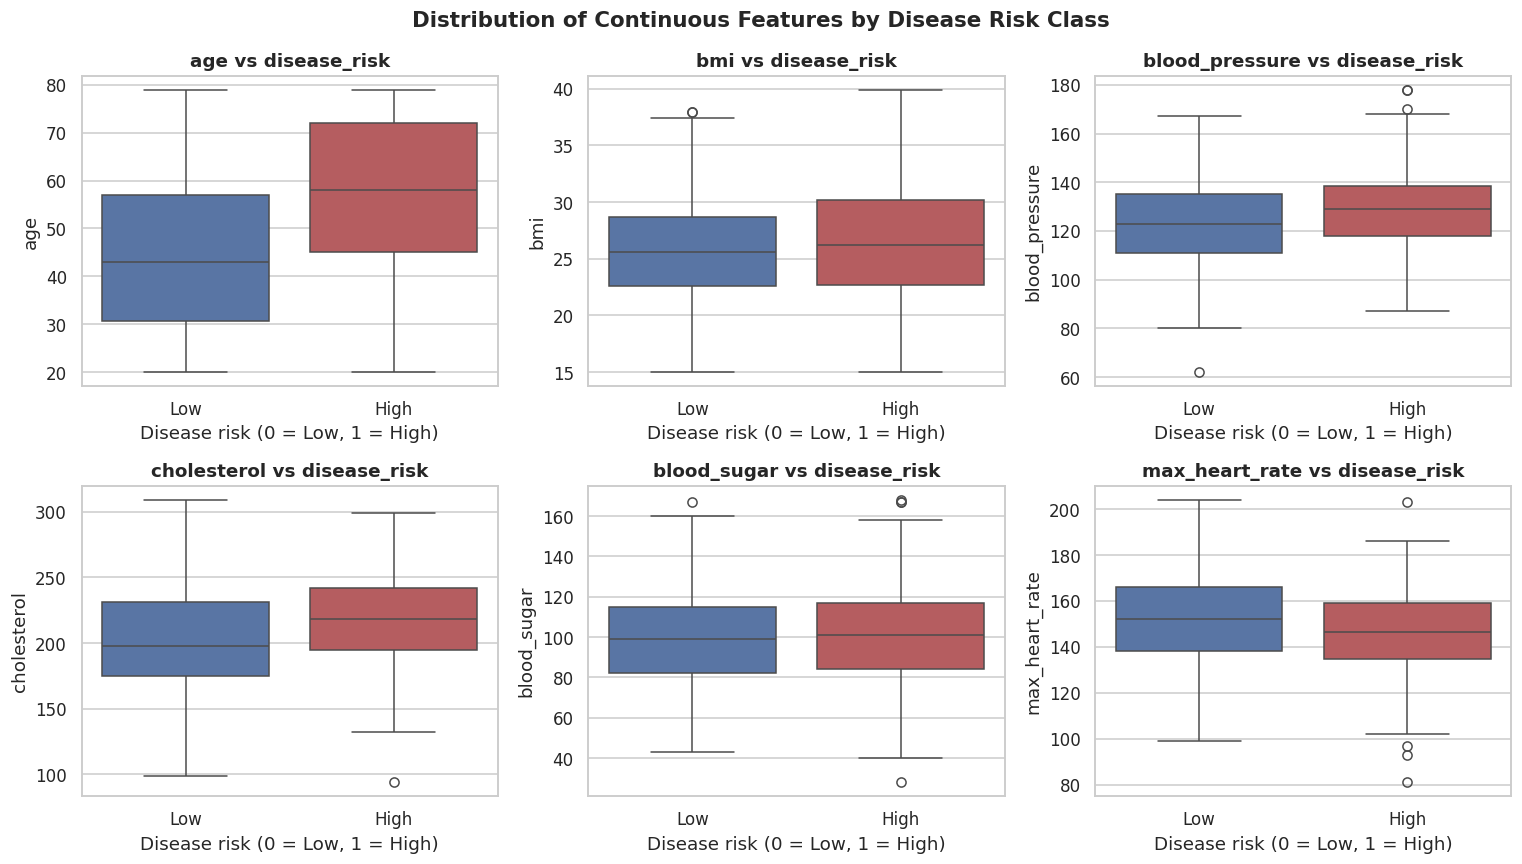

In [8]:
continuous = ["age", "bmi", "blood_pressure", "cholesterol", "blood_sugar", "max_heart_rate"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), continuous):
    sns.boxplot(data=df, x="disease_risk", y=col, hue="disease_risk",
                palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
    ax.set_title(f"{col} vs disease_risk")
    ax.set_xlabel("Disease risk (0 = Low, 1 = High)")
    ax.set_ylabel(col)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low", "High"])

fig.suptitle("Distribution of Continuous Features by Disease Risk Class",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
group_means = df.groupby("disease_risk")[continuous].mean().T
group_means.columns = ["Low Risk (0)", "High Risk (1)"]
group_means["Difference"] = group_means["High Risk (1)"] - group_means["Low Risk (0)"]
print("Mean feature value by class:\n")
print(group_means.round(2).to_string())

Mean feature value by class:

                Low Risk (0)  High Risk (1)  Difference
age                    44.40          56.58       12.18
bmi                    25.66          26.43        0.77
blood_pressure        122.45         128.33        5.88
cholesterol           203.02         216.69       13.67
blood_sugar            97.27         101.64        4.37
max_heart_rate        152.62         145.38       -7.24


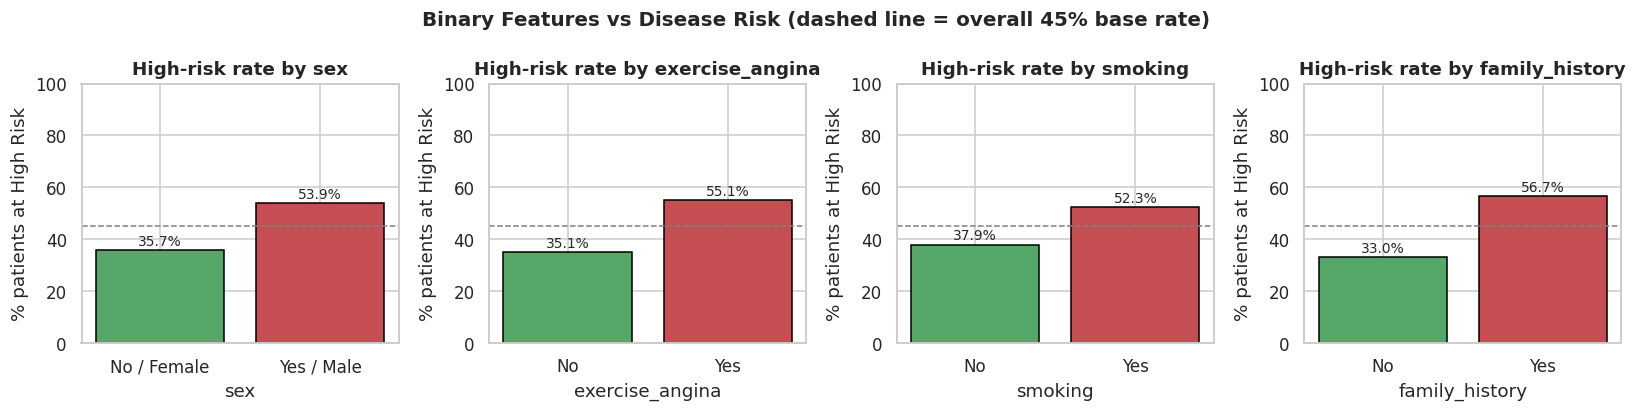

In [10]:
binary = ["sex", "exercise_angina", "smoking", "family_history"]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
for ax, col in zip(axes, binary):
    rates = df.groupby(col)["disease_risk"].mean() * 100
    ax.bar(["No / Female" if col == "sex" else "No",
            "Yes / Male" if col == "sex" else "Yes"],
           rates.values, color=["#55A868", "#C44E52"], edgecolor="black")
    ax.set_title(f"High-risk rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("% patients at High Risk")
    ax.set_ylim(0, 100)
    ax.axhline(df["disease_risk"].mean() * 100, ls="--", c="grey", lw=1)
    for i, v in enumerate(rates.values):
        ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9)

fig.suptitle("Binary Features vs Disease Risk (dashed line = overall 45% base rate)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

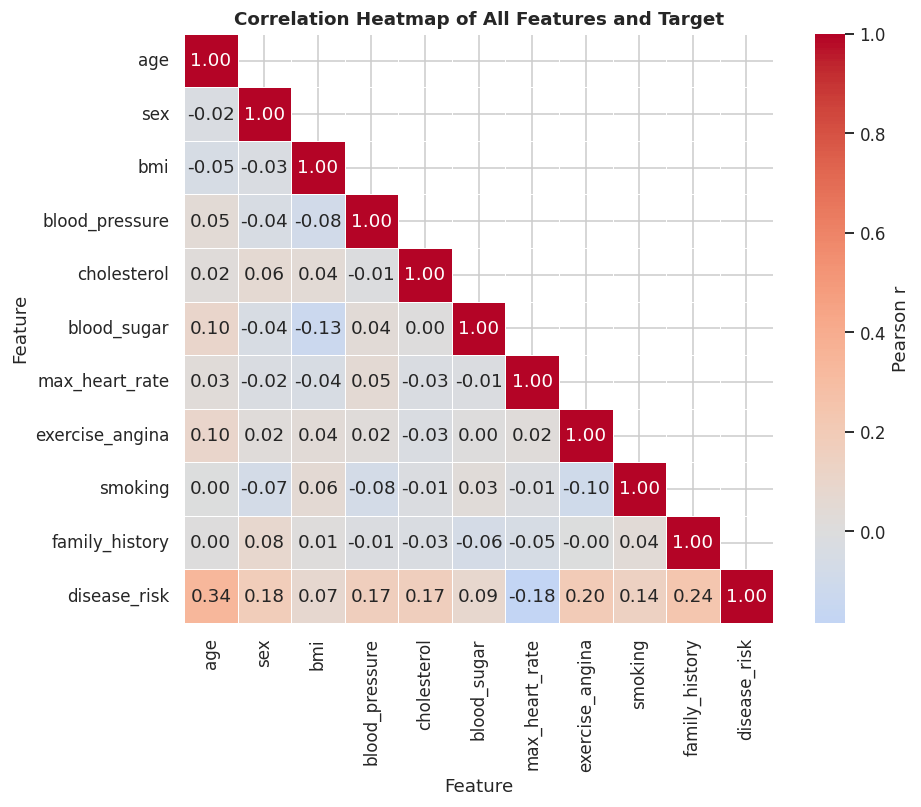

In [11]:
fig, ax = plt.subplots(figsize=(9.5, 7.5))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Correlation Heatmap of All Features and Target")
ax.set_xlabel("Feature")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

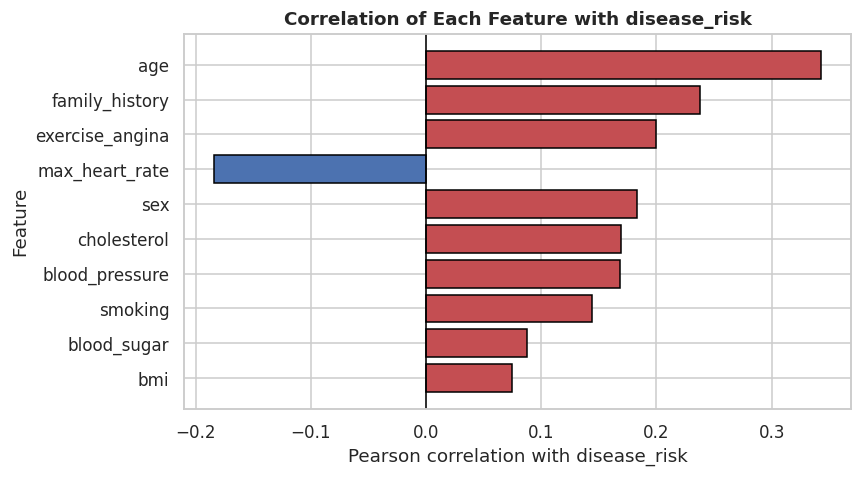

age                0.343
family_history     0.238
exercise_angina    0.200
max_heart_rate    -0.184
sex                0.183
cholesterol        0.169
blood_pressure     0.168
smoking            0.144
blood_sugar        0.087
bmi                0.075


In [12]:
target_corr = (df.corr(numeric_only=True)["disease_risk"]
                 .drop("disease_risk")
                 .sort_values(key=abs, ascending=False))

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in target_corr.values]
ax.barh(target_corr.index[::-1], target_corr.values[::-1], color=colors[::-1],
        edgecolor="black")
ax.axvline(0, c="black", lw=1)
ax.set_title("Correlation of Each Feature with disease_risk")
ax.set_xlabel("Pearson correlation with disease_risk")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print(target_corr.round(3).to_string())

### What the EDA showing that

1. **`age` is the strongest single predictor** where r approximates 0.34. Where in High risk patients are noticeably are older and the boxplot medians are clearly separated.
2. **`family_history`, `exercise_angina`, `sex`, `cholesterol` and `blood_pressure`** all show weak to moderate positive association r between 0.17 and 0.24. Being male and having a family history or exercise induced angina each lifts the high risk rate well above the 45% base rate.
3. **`max_heart_rate` is the only negative correlate** where r ~ -0.18 with a lower achievable maximum heart rate that goes with a higher risk which is clinically sensible.
4. **`bmi` and `blood_sugar` are close to useless on their own** since r < 0.09 We expect them to contribute little to any model.
5. **No multicollinearity.** Feature to feature correlations are all near zero, so every feature carries independent information. This matters later since it is a very favourable situation for Naive Bayes whose independence assumption is usually its weakness.
6. **No single feature separates the classes cleanly**. All boxplots overlap heavily the signal is spread thinly across many weak features which predicts that *additive* models Logistic Regression, linear SVM will do well and a *partitioning* model with a single Decision Tree will struggle.

---
# Part 2 Preprocessing

## 2.1 Handling missing values: method and justification

**Chosen method is the median imputation with the median computed on the training set only.**

Why impute rather than drop as there Only 24 cells of which 0.5% of all data are missing which is spread over 24 different patients. Dropping those rows would discard 6% of an already small 400 row dataset a needless loss of information.

Why the median rather than the mean as all three affected columns `bmi`, `cholesterol`, `blood_sugar` are continuous clinical measurements with visible outliers in the boxplots above. The median is robust to those outliers so it is a safer central estimate than the mean. It is also guaranteed to be a physically plausible value for the variable.

Why compute it on the training set only as computing the median over the full dataset lets information from the test set leak into training and produces an optimistically biased score. The correct procedure is to fit the imputer on the training split and apply those same values to the test split. That is what is done below and it is why the split at section 2.2 is executed before the
imputation is applied.

In [13]:
print("Median of the three affected columns (full data, for reference only):")
print(df[["bmi", "cholesterol", "blood_sugar"]].median().round(2).to_string())
print("\nMean for comparison:")
print(df[["bmi", "cholesterol", "blood_sugar"]].mean().round(2).to_string())

Median of the three affected columns (full data, for reference only):
bmi             26.0
cholesterol    210.5
blood_sugar    100.0

Mean for comparison:
bmi             26.00
cholesterol    209.09
blood_sugar     99.27


## 2.2 Split into features X and target y

In [14]:
X = df.drop(columns="disease_risk")
y = df["disease_risk"]

feature_names = list(X.columns)
print(f"X shape: {X.shape}   ({len(feature_names)} features)")
print(f"y shape: {y.shape}   (target: disease_risk)")
print("\nFeatures:", ", ".join(feature_names))

X shape: (400, 10)   (10 features)
y shape: (400,)   (target: disease_risk)

Features: age, sex, bmi, blood_pressure, cholesterol, blood_sugar, max_heart_rate, exercise_angina, smoking, family_history


## 2.3 Train/test split 80/20, `random_state=42`

stratify=y keeps the 55/45 class balance identical in both splits. Without it, random chance could hand the test set a noticeably different class mix and distort every metric.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} patients")
print(f"Test set    : {X_test.shape[0]} patients")
print("\nClass balance check (% High Risk):")
print(f"  Full data : {y.mean() * 100:.1f}%")
print(f"  Train     : {y_train.mean() * 100:.1f}%")
print(f"  Test      : {y_test.mean() * 100:.1f}%")

Training set: 320 patients
Test set    : 80 patients

Class balance check (% High Risk):
  Full data : 45.0%
  Train     : 45.0%
  Test      : 45.0%


In [16]:
# Apply the median imputation decided in B.5 -- fitted on TRAIN only, applied to both splits.
imputer = SimpleImputer(strategy="median")
X_train_imp = pd.DataFrame(imputer.fit_transform(X_train),
                           columns=feature_names, index=X_train.index)
X_test_imp = pd.DataFrame(imputer.transform(X_test),
                          columns=feature_names, index=X_test.index)

print("Imputation values learned from the training set:")
for col, val in zip(feature_names, imputer.statistics_):
    if col in ["bmi", "cholesterol", "blood_sugar"]:
        print(f"  {col:<15} -> {val:.2f}")

print(f"\nMissing values remaining -- train: {int(X_train_imp.isna().sum().sum())}, "
      f"test: {int(X_test_imp.isna().sum().sum())}")

Imputation values learned from the training set:
  bmi             -> 26.00
  cholesterol     -> 211.00
  blood_sugar     -> 101.00

Missing values remaining -- train: 0, test: 0


## 2.4 Feature scaling which models need it and why

Scaling is not a blanket step but why it matters for some algorithms and is irrelevant to others.

| Model | Scale-sensitive? | Reason |
|---|---|---|
| **Logistic Regression** | **Yes** | The L2 penalty shrinks coefficients toward zero. Unscaled, a feature measured in hundreds (`cholesterol` around 210) gets a tiny coefficient and is penalised differently from one measured in tens (`bmi` around 26), so the regularisation becomes arbitrary. Gradient-based solvers also converge far faster on standardised inputs. |
| **SVM (linear & RBF)** | **Yes, critically** | SVMs maximise a geometric margin, and the RBF kernel is a function of Euclidean distance. A feature with a large numeric range dominates that distance outright, so `cholesterol` would effectively decide every prediction while `sex` would be ignored. |
| **Naive Bayes (GaussianNB)** | **No** | It fits a separate mean and variance per feature per class. Rescaling a feature rescales its mean and variance identically, so the resulting probabilities are unchanged. |
| **Decision Tree** | **No** | Splits are chosen by thresholding one feature at a time (`age <= 54.5`). Any monotonic rescaling maps that threshold to an equivalent one and produces exactly the same tree. |
| **KNN (bonus)** | **Yes** | Purely distance-based, same argument as the SVM. |

Therefore `StandardScaler` is fitted **on the training set only** and used for Logistic Regression, SVM and KNN. Naive Bayes and the Decision Tree are trained on the unscaled imputed data to show the point and because the original units keep the tree's split thresholds human readable.

In [17]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_imp),
                              columns=feature_names, index=X_train_imp.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_imp),
                             columns=feature_names, index=X_test_imp.index)

print("Before scaling (train means / std):")
print(X_train_imp[["age", "cholesterol", "bmi"]].agg(["mean", "std"]).round(2).to_string())
print("\nAfter scaling (train means / std):")
print(X_train_scaled[["age", "cholesterol", "bmi"]].agg(["mean", "std"]).round(2).to_string())

Before scaling (train means / std):
        age  cholesterol    bmi
mean  50.15       209.14  26.08
std   17.81        39.87   5.03

After scaling (train means / std):
      age  cholesterol  bmi
mean  0.0         -0.0 -0.0
std   1.0          1.0  1.0


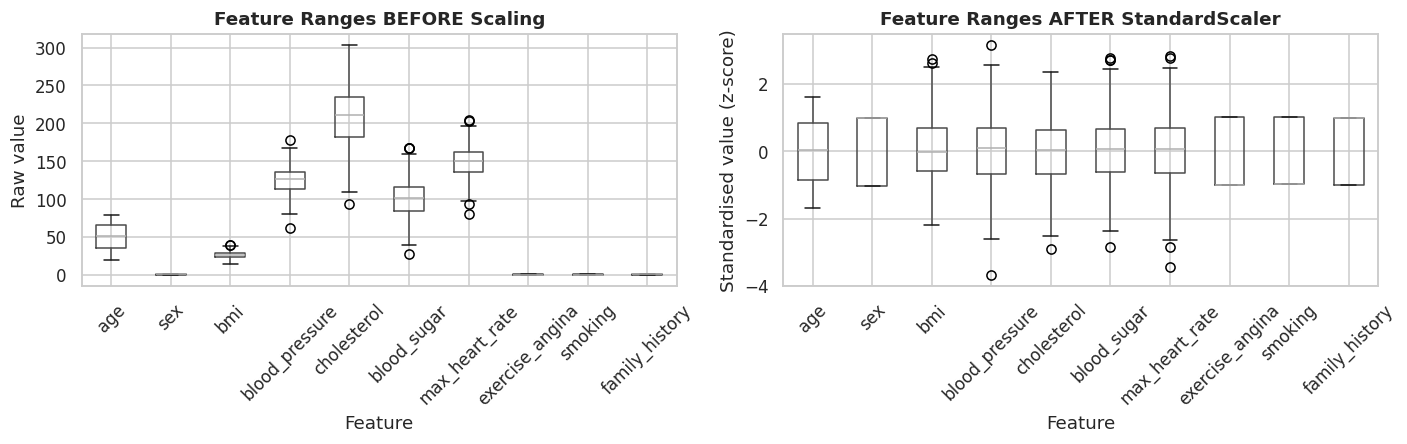

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
X_train_imp.boxplot(ax=axes[0], rot=45)
axes[0].set_title("Feature Ranges BEFORE Scaling")
axes[0].set_xlabel("Feature")
axes[0].set_ylabel("Raw value")

X_train_scaled.boxplot(ax=axes[1], rot=45)
axes[1].set_title("Feature Ranges AFTER StandardScaler")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Standardised value (z-score)")

plt.tight_layout()
plt.show()

The left panel makes the problem concrete: `cholesterol` and `blood_pressure` span hundreds of
units while the binary features live in [0, 1]. For a distance-based model that is not a detail,
it is the whole prediction. After standardisation every feature contributes on equal terms.

---
# Section 3 Model Training

Each model is trained twice:

1. **Default hyperparameters** is the out of the box baseline.
2. **Tuned** `GridSearchCV` search with 5 fold stratified cross validation on the training data set only.

**A note on the tuning metric.** The search optimises F1 but not ROC-AUC. as ROC-AUC measures only how well a model ranks patients and ignores the decision threshold entirely, so on this dataset it happily selects heavily regularised SVMs that achieve a good AUC while predicting "Low Risk" for every single patient. F1 is threshold aware and balances precision against recall on the minority high risk class, so it rejects those degenerate solutions.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def tune(estimator, grid, X_tr, name, scoring="f1"):
    """Run a 5-fold grid search on the training set and report the winner."""
    search = GridSearchCV(estimator, grid, cv=cv, scoring=scoring, n_jobs=-1)
    search.fit(X_tr, y_train)
    print(f"--- {name} ---")
    print(f"Combinations tried : {len(search.cv_results_['params'])}")
    print(f"Best parameters    : {search.best_params_}")
    print(f"Best CV {scoring:<10}: {search.best_score_:.4f}")
    return search.best_estimator_, search

## 3.1 Logistic Regression

A linear model that estimates P(High Risk) through the logistic function. Trained on scaled data. Tuning targets `C` the inverse regularisation strength. A small `C` means heavy shrinkage of the coefficients.

In [20]:
lr_default = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_default.fit(X_train_scaled, y_train)
print("Logistic Regression (default) trained.")
print(f"Training accuracy: {lr_default.score(X_train_scaled, y_train):.4f}")

lr_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
}
lr_best, lr_search = tune(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    lr_grid, X_train_scaled, "Logistic Regression tuning"
)

Logistic Regression (default) trained.
Training accuracy: 0.7906
--- Logistic Regression tuning ---
Combinations tried : 12
Best parameters    : {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best CV f1        : 0.7530


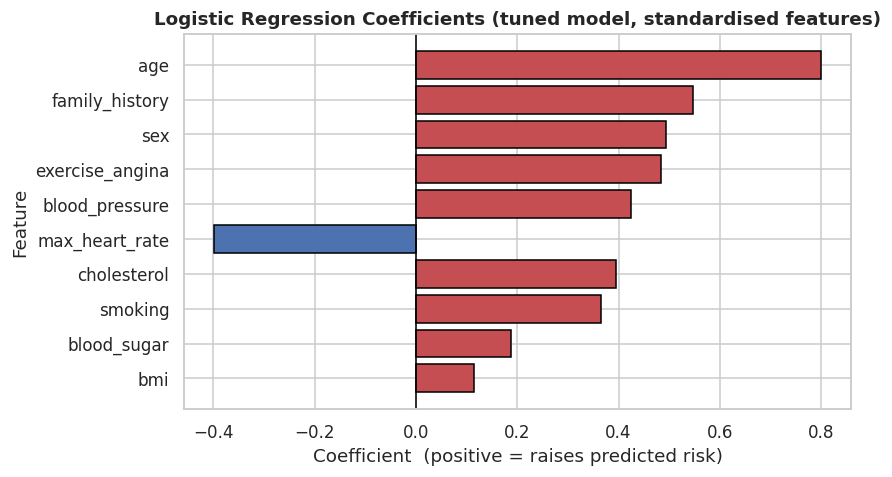

Odds ratio per 1 standard deviation increase:

age                2.225
family_history     1.727
sex                1.639
exercise_angina    1.622
blood_pressure     1.530
max_heart_rate     0.672
cholesterol        1.485
smoking            1.442
blood_sugar        1.206
bmi                1.122


In [21]:
coefs = pd.Series(lr_best.coef_[0], index=feature_names).sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in coefs.values]
ax.barh(coefs.index[::-1], coefs.values[::-1], color=colors[::-1], edgecolor="black")
ax.axvline(0, c="black", lw=1)
ax.set_title("Logistic Regression Coefficients (tuned model, standardised features)")
ax.set_xlabel("Coefficient  (positive = raises predicted risk)")
ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

print("Odds ratio per 1 standard deviation increase:\n")
print(np.exp(coefs).round(3).to_string())

Since the features are standardised these coefficients are directly comparable. `age` carries by far the most weight, and `max_heart_rate` is the only strong negative, both exactly as the EDA predicted. Being able to read a model this directly is a real advantage in a clinical setting.

## 3.2 Support Vector Machine linear and RBF kernels

Trained on scaled data again `probability=True` enables `predict_proba` which is needed for ROC-AUC. Both kernels are fitted with defaults rather then a single grid searches over kernel which is `C` and `gamma` together in this case.

In [22]:
svm_linear = SVC(kernel="linear", probability=True, random_state=RANDOM_STATE)
svm_linear.fit(X_train_scaled, y_train)
print(f"SVM linear (default) training accuracy: {svm_linear.score(X_train_scaled, y_train):.4f}")

svm_rbf = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
svm_rbf.fit(X_train_scaled, y_train)
print(f"SVM RBF    (default) training accuracy: {svm_rbf.score(X_train_scaled, y_train):.4f}")
print(f"\nSupport vectors used. Linear: {svm_linear.n_support_.sum()}, "
      f"RBF: {svm_rbf.n_support_.sum()} (of {len(X_train_scaled)} training points)")

SVM linear (default) training accuracy: 0.7969
SVM RBF    (default) training accuracy: 0.8562

Support vectors used. Linear: 168, RBF: 220 (of 320 training points)


In [23]:
svm_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", 0.01, 0.1],
}
svm_best, svm_search = tune(
    SVC(probability=True, random_state=RANDOM_STATE),
    svm_grid, X_train_scaled, "SVM tuning"
)

--- SVM tuning ---
Combinations tried : 24
Best parameters    : {'C': 10, 'gamma': 'scale', 'kernel': 'linear'}
Best CV f1        : 0.7473


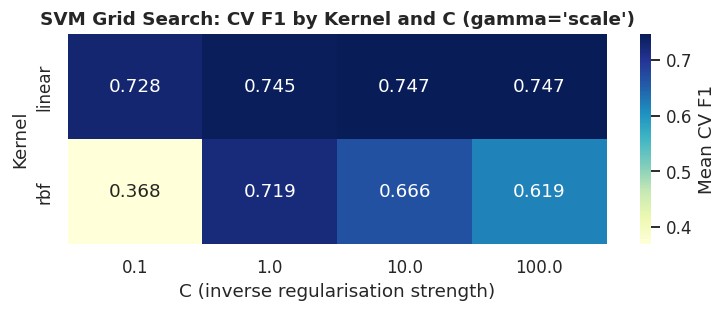

In [24]:
res = pd.DataFrame(svm_search.cv_results_)
pivot = (res[res.param_gamma == "scale"]
         .pivot_table(index="param_kernel", columns="param_C", values="mean_test_score"))

fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu",
            cbar_kws={"label": "Mean CV F1"}, ax=ax)
ax.set_title("SVM Grid Search: CV F1 by Kernel and C (gamma='scale')")
ax.set_xlabel("C (inverse regularisation strength)")
ax.set_ylabel("Kernel")
plt.tight_layout()
plt.show()

The linear kernel matches or beats the RBF kernel across the grid. That is informative rather than disappointing as it says the class boundary in this dataset really is close to linear, so the extra flexibility of the RBF kernel buys nothing and only adds variance.

## 3.3 Naive Bayes (GaussianNB)

Trained on unscaled imputed data set since GaussianNB is scale invariant (see section 2.4 for more details). It assumes each feature is normally distributed within each class and that features are conditionally independent. The only real hyperparameter is `var_smoothing` a stability constant added to the
variances.

In [25]:
nb_default = GaussianNB()
nb_default.fit(X_train_imp, y_train)
print(f"GaussianNB (default) training accuracy: {nb_default.score(X_train_imp, y_train):.4f}")

nb_grid = {"var_smoothing": np.logspace(-11, -1, 20)}
nb_best, nb_search = tune(GaussianNB(), nb_grid, X_train_imp, "Naive Bayes tuning")

GaussianNB (default) training accuracy: 0.7906
--- Naive Bayes tuning ---
Combinations tried : 20
Best parameters    : {'var_smoothing': np.float64(1e-11)}
Best CV f1        : 0.7480


In [26]:
# Sanity check on the independence assumption that Naive Bayes relies on.
off_diag = X_train_imp.corr().where(~np.eye(len(feature_names), dtype=bool)).abs()
print(f"Mean |correlation| between features : {off_diag.stack().mean():.3f}")
print(f"Max  |correlation| between features : {off_diag.stack().max():.3f}")
print("\nThe conditional-independence assumption is close to satisfied here,")
print("which is why Naive Bayes stays competitive despite being the simplest model.")

Mean |correlation| between features : 0.044
Max  |correlation| between features : 0.150

The conditional-independence assumption is close to satisfied here,
which is why Naive Bayes stays competitive despite being the simplest model.


## 3.4 Decision Tree Classifier

Trained on unscaled data also scale-invariant, and raw units keep the split thresholds readable. An unrestricted tree will grow until every training leaf pure so tuning targets `max_depth` and `min_samples_leaf` are the two levers that control overfitting here.

In [27]:
dt_default = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_default.fit(X_train_imp, y_train)
print(f"Decision Tree (default) training accuracy: {dt_default.score(X_train_imp, y_train):.4f}")
print(f"Tree depth  : {dt_default.get_depth()}")
print(f"Leaf nodes  : {dt_default.get_n_leaves()}")
print("\n>>> 100% training accuracy with a deep tree is the textbook signature of overfitting:")
print(">>> the tree has memorised the training set rather than learned a general rule.")

dt_grid = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_leaf": [1, 5, 10, 20],
    "criterion": ["gini", "entropy"],
}
dt_best, dt_search = tune(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    dt_grid, X_train_imp, "Decision Tree tuning"
)
print(f"\nTuned tree. Depth: {dt_best.get_depth()}, leaves: {dt_best.get_n_leaves()}, "
      f"training accuracy: {dt_best.score(X_train_imp, y_train):.4f}")

Decision Tree (default) training accuracy: 1.0000
Tree depth  : 10
Leaf nodes  : 67

>>> 100% training accuracy with a deep tree is the textbook signature of overfitting:
>>> the tree has memorised the training set rather than learned a general rule.
--- Decision Tree tuning ---
Combinations tried : 64
Best parameters    : {'criterion': 'entropy', 'max_depth': 4, 'min_samples_leaf': 20}
Best CV f1        : 0.6521

Tuned tree. Depth: 4, leaves: 12, training accuracy: 0.7594


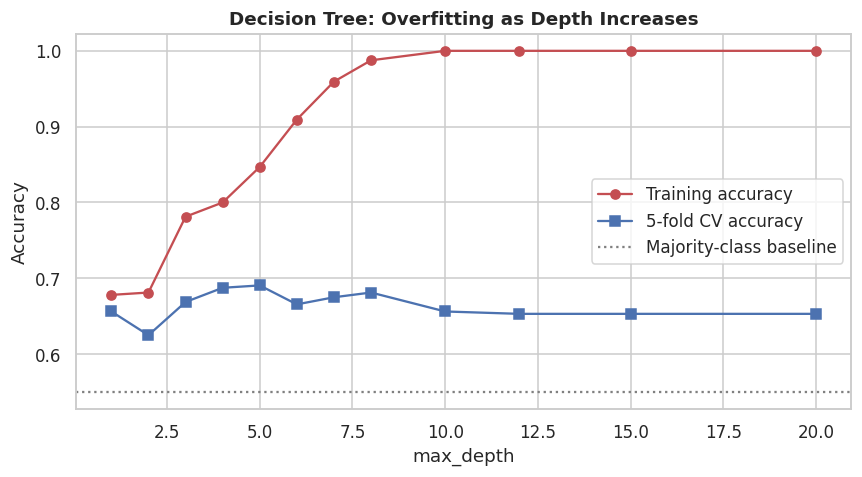

Training accuracy climbs to 1.00 while CV accuracy flattens then falls.
The widening gap between the two curves IS overfitting, made visible.


In [28]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]
train_scores, cv_scores = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    t.fit(X_train_imp, y_train)
    train_scores.append(t.score(X_train_imp, y_train))
    cv_scores.append(cross_val_score(t, X_train_imp, y_train, cv=cv, scoring="accuracy").mean())

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(depths, train_scores, "o-", label="Training accuracy", color="#C44E52")
ax.plot(depths, cv_scores, "s-", label="5-fold CV accuracy", color="#4C72B0")
ax.axhline(y_train.value_counts(normalize=True).max(), ls=":", c="grey",
           label="Majority-class baseline")
ax.set_title("Decision Tree: Overfitting as Depth Increases")
ax.set_xlabel("max_depth")
ax.set_ylabel("Accuracy")
ax.legend()
plt.tight_layout()
plt.show()

print("Training accuracy climbs to 1.00 while CV accuracy flattens then falls.")
print("The widening gap between the two curves IS overfitting, made visible.")

---
# Section 4 Evaluation

All four tuned models are now scored on the **held out test sets**, which has not influenced training or hyperparameter selection in any way.

### The metrics in plain terms for this problem are

- **Accuracy** share of all patients classified correctly. Must beat the 55% majority baseline.
- **Precision**: of the patients flagged high risk. Low precision = false
  alarms, unnecessary follow up tests and patient anxiety.
- **Recall sensitivity**: of the patients who are high risk. Low recall = missed cases as the dangerous failure in a screening context.
- **F1**: harmonic mean of precision and recall. It is a single number that punishes lopsided models.
- **ROC-AUC**: probability that a random high risk patient is ranked above a random low risk one. It is Threshold independent so it measures the quality of the underlying risk score itself.

In [29]:
def evaluate(name, model, X_eval, y_true=y_test):
    """Compute the full metric set for one fitted model on the test set."""
    y_pred = model.predict(X_eval)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_eval)[:, 1]
    else:
        y_score = model.decision_function(X_eval)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "_pred": y_pred,
        "_score": y_score,
    }

# The four required models, tuned versions, each on the data representation it needs.
models = {
    "Logistic Regression": (lr_best, X_test_scaled),
    "SVM":                 (svm_best, X_test_scaled),
    "Naive Bayes":         (nb_best,  X_test_imp),
    "Decision Tree":       (dt_best,  X_test_imp),
}

results = {name: evaluate(name, m, Xt) for name, (m, Xt) in models.items()}
print("All four models evaluated on the test set.")

All four models evaluated on the test set.


## 4.1 Per model metrics and classification reports

In [30]:
for name, (model, X_eval) in models.items():
    r = results[name]
    print("=" * 66)
    print(f"  {name.upper()}")
    print("=" * 66)
    print(f"Accuracy : {r['Accuracy']:.4f}")
    print(f"ROC-AUC  : {r['ROC-AUC']:.4f}\n")
    print(classification_report(y_test, r["_pred"],
                               target_names=["Low Risk (0)", "High Risk (1)"],
                               digits=3))

  LOGISTIC REGRESSION
Accuracy : 0.7625
ROC-AUC  : 0.7872

               precision    recall  f1-score   support

 Low Risk (0)      0.791     0.773     0.782        44
High Risk (1)      0.730     0.750     0.740        36

     accuracy                          0.762        80
    macro avg      0.760     0.761     0.761        80
 weighted avg      0.763     0.762     0.763        80

  SVM
Accuracy : 0.7000
ROC-AUC  : 0.7847

               precision    recall  f1-score   support

 Low Risk (0)      0.738     0.705     0.721        44
High Risk (1)      0.658     0.694     0.676        36

     accuracy                          0.700        80
    macro avg      0.698     0.699     0.698        80
 weighted avg      0.702     0.700     0.701        80

  NAIVE BAYES
Accuracy : 0.7000
ROC-AUC  : 0.7670

               precision    recall  f1-score   support

 Low Risk (0)      0.738     0.705     0.721        44
High Risk (1)      0.658     0.694     0.676        36

     accuracy 

## 4.2 Confusion matrices

Read it as rows = truth and columns = prediction. The bottom left cell is the one that matters clinically as those are high risk patients the model sent home as low risk.

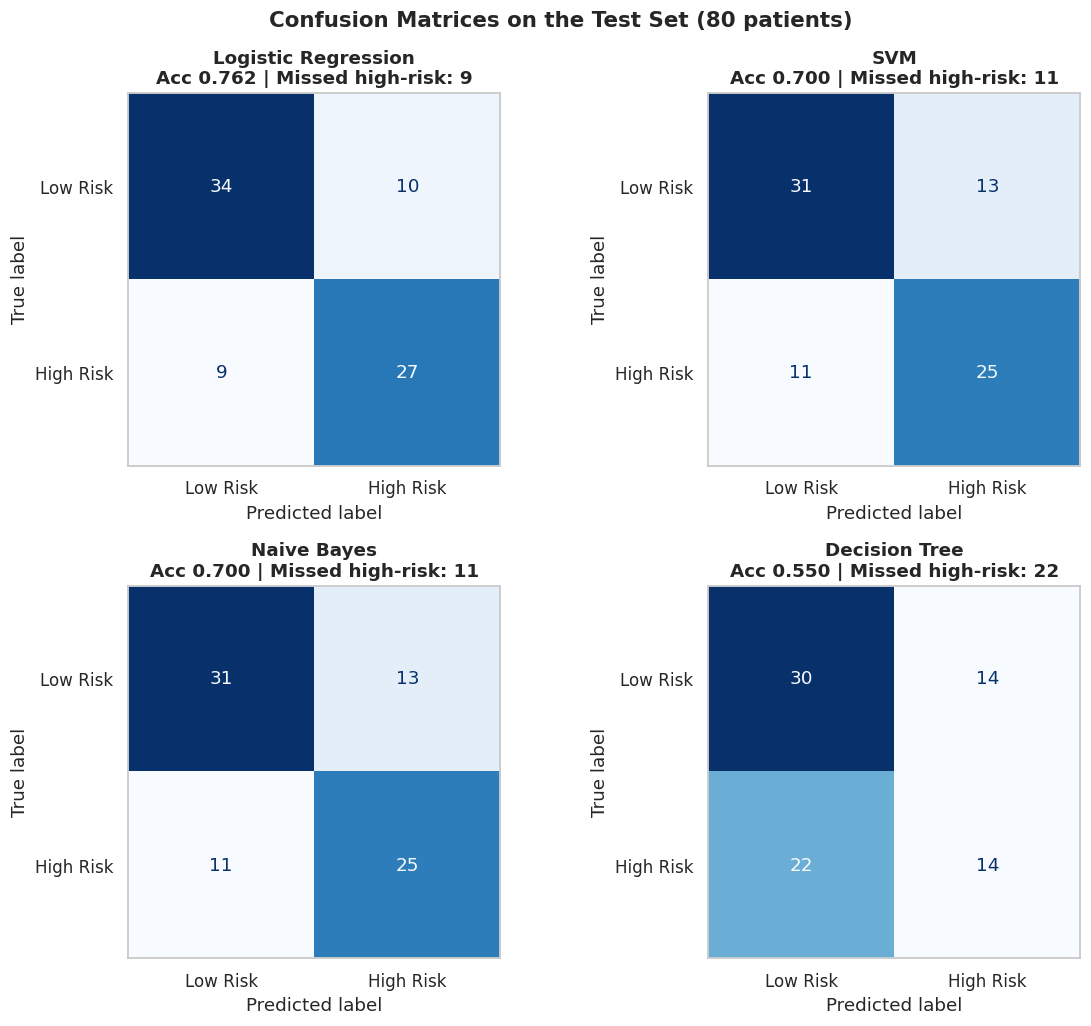

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9.5))
for ax, (name, r) in zip(axes.ravel(), results.items()):
    cm = confusion_matrix(y_test, r["_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Low Risk", "High Risk"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f"{name}\nAcc {r['Accuracy']:.3f} | Missed high-risk: {fn}")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.grid(False)

fig.suptitle("Confusion Matrices on the Test Set (80 patients)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [32]:
breakdown = []
for name, r in results.items():
    tn, fp, fn, tp = confusion_matrix(y_test, r["_pred"]).ravel()
    breakdown.append({
        "Model": name,
        "True Neg": tn, "False Pos": fp, "False Neg": fn, "True Pos": tp,
        "Missed high-risk patients": fn,
        "False alarms": fp,
    })
print(pd.DataFrame(breakdown).set_index("Model").to_string())

                     True Neg  False Pos  False Neg  True Pos  Missed high-risk patients  False alarms
Model                                                                                                 
Logistic Regression        34         10          9        27                          9            10
SVM                        31         13         11        25                         11            13
Naive Bayes                31         13         11        25                         11            13
Decision Tree              30         14         22        14                         22            14


## 4.3 ROC curves

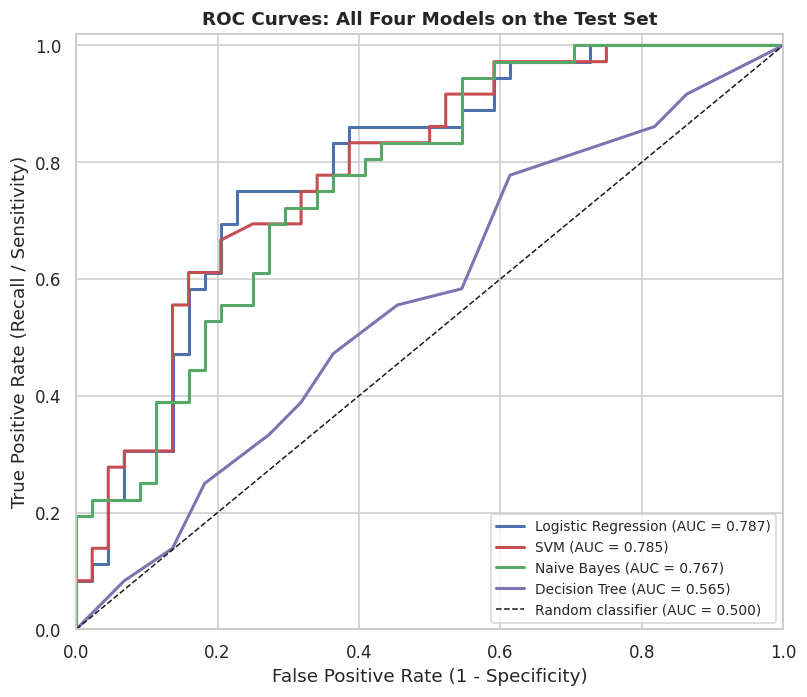

In [33]:
fig, ax = plt.subplots(figsize=(7.5, 6.5))
palette = ["#4C72B0", "#C44E52", "#55A868", "#8172B2"]

for (name, r), c in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, r["_score"])
    ax.plot(fpr, tpr, lw=2, color=c, label=f"{name} (AUC = {r['ROC-AUC']:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier (AUC = 0.500)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.set_title("ROC Curves: All Four Models on the Test Set")
ax.set_xlabel("False Positive Rate (1 - Specificity)")
ax.set_ylabel("True Positive Rate (Recall / Sensitivity)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 4.4 Summary comparison table

In [34]:
summary = (pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                         for r in results.values()])
             .set_index("Model")
             .round(4))

print("=" * 76)
print("  TEST-SET PERFORMANCE: FOUR CLASSIFIERS (tuned)")
print("=" * 76)
print(summary.to_string())
print("=" * 76)
print(f"\nMajority-class baseline accuracy: {max(y_test.mean(), 1 - y_test.mean()):.4f}")
summary.style.background_gradient(cmap="RdYlGn", axis=0).format("{:.4f}")

  TEST-SET PERFORMANCE: FOUR CLASSIFIERS (tuned)
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7625     0.7297  0.7500    0.7397   0.7872
SVM                    0.7000     0.6579  0.6944    0.6757   0.7847
Naive Bayes            0.7000     0.6579  0.6944    0.6757   0.7670
Decision Tree          0.5500     0.5000  0.3889    0.4375   0.5653

Majority-class baseline accuracy: 0.5500


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.7625,0.7297,0.7500,0.7397,0.7872
SVM,0.7000,0.6579,0.6944,0.6757,0.7847
Naive Bayes,0.7000,0.6579,0.6944,0.6757,0.7670
Decision Tree,0.5500,0.5000,0.3889,0.4375,0.5653


In [35]:
# The same comparison for the default (untuned) models, to show what tuning bought.
defaults = {
    "Logistic Regression": (lr_default, X_test_scaled),
    "SVM (linear)":        (svm_linear, X_test_scaled),
    "SVM (RBF)":           (svm_rbf,    X_test_scaled),
    "Naive Bayes":         (nb_default, X_test_imp),
    "Decision Tree":       (dt_default, X_test_imp),
}
default_summary = (pd.DataFrame([{k: v for k, v in evaluate(n, m, Xt).items()
                                  if not k.startswith("_")}
                                 for n, (m, Xt) in defaults.items()])
                     .set_index("Model").round(4))

print("DEFAULT HYPERPARAMETERS: test-set performance")
print("=" * 76)
print(default_summary.to_string())

DEFAULT HYPERPARAMETERS: test-set performance
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7625     0.7297  0.7500    0.7397   0.7904
SVM (linear)           0.7000     0.6579  0.6944    0.6757   0.7841
SVM (RBF)              0.6875     0.6774  0.5833    0.6269   0.7727
Naive Bayes            0.7000     0.6579  0.6944    0.6757   0.7670
Decision Tree          0.5375     0.4848  0.4444    0.4638   0.5290


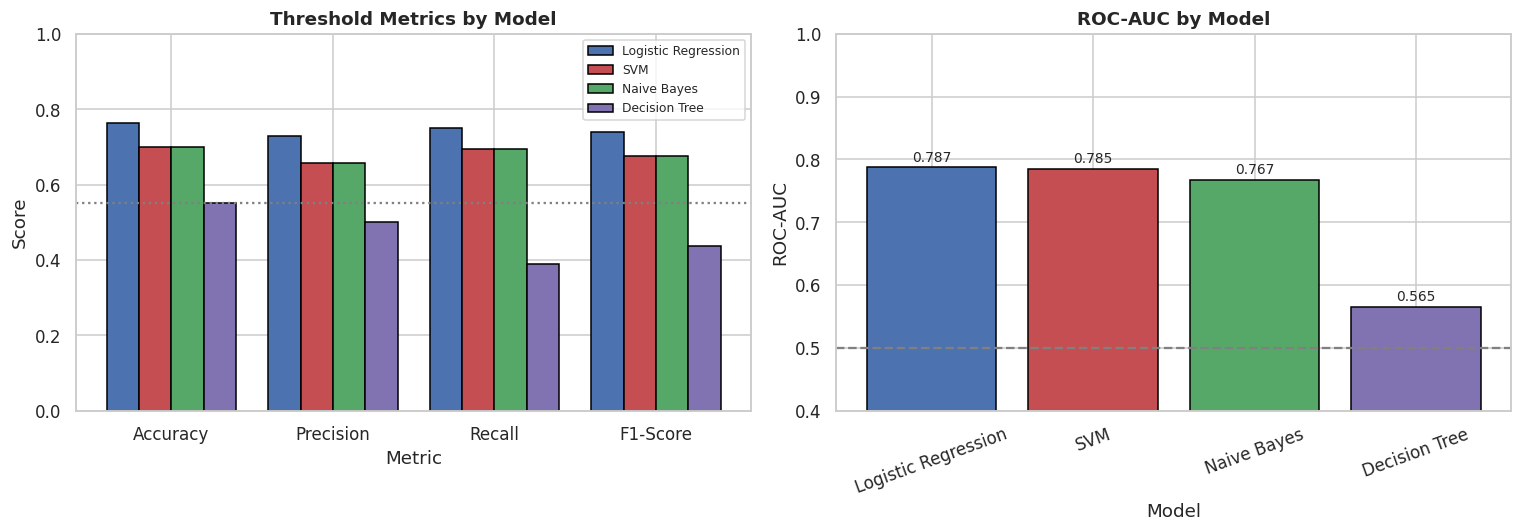

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
xpos = np.arange(len(metrics))
width = 0.2
for i, (name, row) in enumerate(summary.iterrows()):
    axes[0].bar(xpos + i * width, [row[m] for m in metrics], width,
                label=name, edgecolor="black", color=palette[i])
axes[0].set_xticks(xpos + width * 1.5)
axes[0].set_xticklabels(metrics)
axes[0].set_title("Threshold Metrics by Model")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=8)
axes[0].axhline(0.55, ls=":", c="grey")

bars = axes[1].bar(summary.index, summary["ROC-AUC"], color=palette, edgecolor="black")
axes[1].set_title("ROC-AUC by Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_ylim(0.4, 1.0)
axes[1].axhline(0.5, ls="--", c="grey")
axes[1].tick_params(axis="x", rotation=20)
for b, v in zip(bars, summary["ROC-AUC"]):
    axes[1].text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

---
# Part 5 Analysis & Conclusion

### 5.1 Which model performed best overall and why?

**Logistic Regression** is the clear winner here as the highest accuracy 0.763 with the best balance of precision and recall F1 = 0.740 and the highest ROC-AUC 0.787. The linear SVM is close behind AUC 0.785, which is not so surprising as both fit a linear decision boundary differ mainly in their loss function. The EDA explains the result. The signal in this dataset is spread thinly across many weakly correlated features such as `age` r ≈ 0.34, and everything else below 0.24, the features are mutually uncorrelated (mean |r| = 0.04) so risk accumulates roughly. That is precisely the structure Logistic Regression assumes and with 320 training rows and 10 features a low variance linear model is exactly the right complexity. Naive Bayes performs respectably
(AUC 0.767) for the same reason which is its independence assumption evn though it is usually the weak point.

### 5.2 Which model performed worst and why?

The **Decision Tree** by a wide margin accuracy 0.550, F1 0.438, AUC 0.565, barely above chance and no better than always predicting "Low Risk". The default tree reached **100% training accuracy** with 67 leaves at depth 10, while cross validated accuracy sat near 0.65 and textbook overfitting was visible as the widening gap in the depth vs accuracy curve. A single tree splits on one feature at a time and when no feature separates the classes cleanly it is forced to carve the space into small, noisy regions that do not generalise. Tuning `max_depth=4`, `min_samples_leaf=20`  lifted AUC from 0.529 to 0.565 but could not fix the fundamental mismatch since the axis aligned splits are the wrong tool for a smooth, additive and multi factor risk gradient.

### 5.3 Precision or Recall for a real medical screening tool?

**Recalling** decisively. The two errors are not symmetric. A false positive means an unnecessary follow up test with cost and anxiety, both recoverable. A false negative means a genuinely high risk patient is told they are fine, and the disease progresses undetected until it is harder or
impossible to treat. Screening exists to catch cases early and a downstream confirmatory test can filter out false alarms. Nothing downstream can recover a patient who was never flagged. Even the best model here misses **9 of the 36 high risk patients** in the test set at the default 0.5 threshold, which is unacceptable for real screening so in deployment the threshold would be
lowered to push recall toward 0.90+ trading precision away deliberately.

### 5.4 Which model would to deploy and why?

**Logistic Regression**, on all three of the criteria that matter:

- **Accuracy**: best on every test set metric, and it holds up under cross validation (AUC 0.834 ± 0.017 vs the tree's 0.693 ± 0.055). Naive Bayes ties it on CV accuracy (0.770 vs 0.767) but loses on F1 and AUC and gives no per feature explanation.
- **Interpretability**: it outputs a coefficient per feature and a calibrated probability so a clinician can see *why* a patient was flagged "age and family history drove this score" and audit it. In regulated medical software that is close to a hard requirement.
- **Speed**: trains in milliseconds and predicts with a single dot product. Trivial to deploy retrain and monitor.

The deciding factor is the probability output where a well calibrated risk score lets the operating threshold be tuned to whatever recall the clinical protocol demands without retraining. An observation that could be made is that at AUC ≈ 0.79 this model is a triage aid for prioritising further testing not a diagnostic instrument.

---
# Bonus Section

1. A fifth model **K-Nearest Neighbors**
2. **5-fold cross-validation** with mean ± std replacing the single train/test split
3. **Decision Tree feature importance**
4. **Decision threshold analysis** putting the recall argument from E.15 into practice

## Bonus 1 K-Nearest Neighbors as a 5th model

Since it is Distance based so it uses the **scaled** data. `n_neighbors` is tuned.

In [46]:
knn_grid = {"n_neighbors": [3, 5, 7, 9, 11, 15, 21, 25], "weights": ["uniform", "distance"]}
knn_best, knn_search = tune(KNeighborsClassifier(), knn_grid, X_train_scaled, "KNN tuning")

results["KNN"] = evaluate("KNN", knn_best, X_test_scaled)
models["KNN"] = (knn_best, X_test_scaled)

summary5 = (pd.DataFrame([{k: v for k, v in r.items() if not k.startswith("_")}
                          for r in results.values()])
              .set_index("Model").round(4))

print("=" * 76)
print("  FIVE-MODEL COMPARISON: TEST SET")
print("=" * 76)
print(summary5.to_string())

--- KNN tuning ---
Combinations tried : 16
Best parameters    : {'n_neighbors': 21, 'weights': 'uniform'}
Best CV f1        : 0.7071
  FIVE-MODEL COMPARISON: TEST SET
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7625     0.7297  0.7500    0.7397   0.7872
SVM                    0.7000     0.6579  0.6944    0.6757   0.7847
Naive Bayes            0.7000     0.6579  0.6944    0.6757   0.7670
Decision Tree          0.5500     0.5000  0.3889    0.4375   0.5653
KNN                    0.6250     0.5882  0.5556    0.5714   0.7374


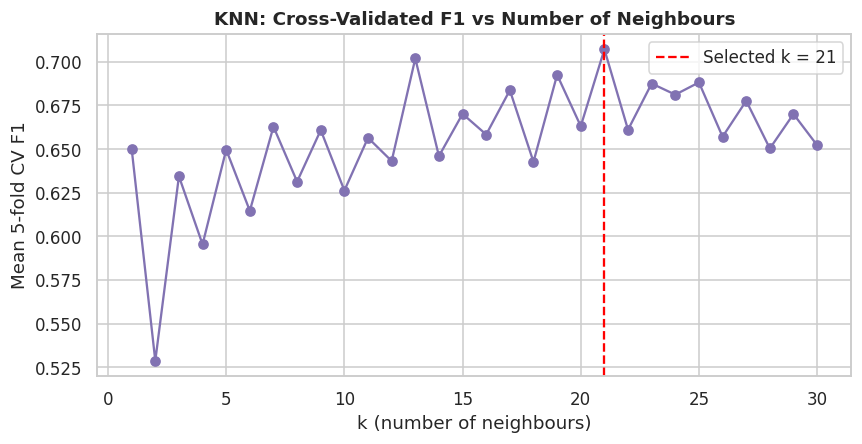

In [38]:
k_range = range(1, 31)
k_scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_scaled, y_train,
                            cv=cv, scoring="f1").mean() for k in k_range]

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(list(k_range), k_scores, "o-", color="#8172B2")
ax.axvline(knn_best.n_neighbors, ls="--", c="red",
           label=f"Selected k = {knn_best.n_neighbors}")
ax.set_title("KNN: Cross-Validated F1 vs Number of Neighbours")
ax.set_xlabel("k (number of neighbours)")
ax.set_ylabel("Mean 5-fold CV F1")
ax.legend()
plt.tight_layout()
plt.show()

KNN lands mid table. With 10 dimensions and only 320 training points the neighbourhoods are sparse and "nearby in feature space" is a weaker notion of similarity than the additive risk structure the linear models exploit. Small `k` values are badly noisy.

## Bonus 2 A 5 fold cross validation instead of a single split

A single 80/20 split evaluates on just 80 patients so the score carries real sampling noise. 5 fold stratified CV uses every patient for testing exactly once and reports a **mean ± std** which shows both the expected performance and its stability.

Each model is wrapped in a `Pipeline` so imputation and scaling are re fitted **inside each fold**. Otherwise the fold's validation data would leak into the preprocessing step.

In [47]:
pipelines = {
    "Logistic Regression": Pipeline([("imp", SimpleImputer(strategy="median")),
                                     ("sc", StandardScaler()),
                                     ("clf", lr_best)]),
    "SVM":                 Pipeline([("imp", SimpleImputer(strategy="median")),
                                     ("sc", StandardScaler()),
                                     ("clf", svm_best)]),
    "Naive Bayes":         Pipeline([("imp", SimpleImputer(strategy="median")),
                                     ("clf", nb_best)]),
    "Decision Tree":       Pipeline([("imp", SimpleImputer(strategy="median")),
                                     ("clf", dt_best)]),
    "KNN":                 Pipeline([("imp", SimpleImputer(strategy="median")),
                                     ("sc", StandardScaler()),
                                     ("clf", knn_best)]),
}

cv_rows, auc_dist = [], {}
for name, pipe in pipelines.items():
    acc = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")
    f1s = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
    auc = cross_val_score(pipe, X, y, cv=cv, scoring="roc_auc")
    auc_dist[name] = auc
    cv_rows.append({
        "Model": name,
        "CV Accuracy": f"{acc.mean():.3f} ± {acc.std():.3f}",
        "CV F1": f"{f1s.mean():.3f} ± {f1s.std():.3f}",
        "CV ROC-AUC": f"{auc.mean():.3f} ± {auc.std():.3f}",
    })

cv_table = pd.DataFrame(cv_rows).set_index("Model")
print("=" * 76)
print("  5-FOLD STRATIFIED CROSS-VALIDATION ON ALL 400 PATIENTS (mean ± std)")
print("=" * 76)
print(cv_table.to_string())

  5-FOLD STRATIFIED CROSS-VALIDATION ON ALL 400 PATIENTS (mean ± std)
                       CV Accuracy          CV F1     CV ROC-AUC
Model                                                           
Logistic Regression  0.767 ± 0.010  0.749 ± 0.010  0.834 ± 0.017
SVM                  0.745 ± 0.017  0.726 ± 0.015  0.831 ± 0.012
Naive Bayes          0.770 ± 0.006  0.748 ± 0.009  0.831 ± 0.016
Decision Tree        0.652 ± 0.045  0.620 ± 0.047  0.693 ± 0.055
KNN                  0.725 ± 0.014  0.672 ± 0.019  0.803 ± 0.018


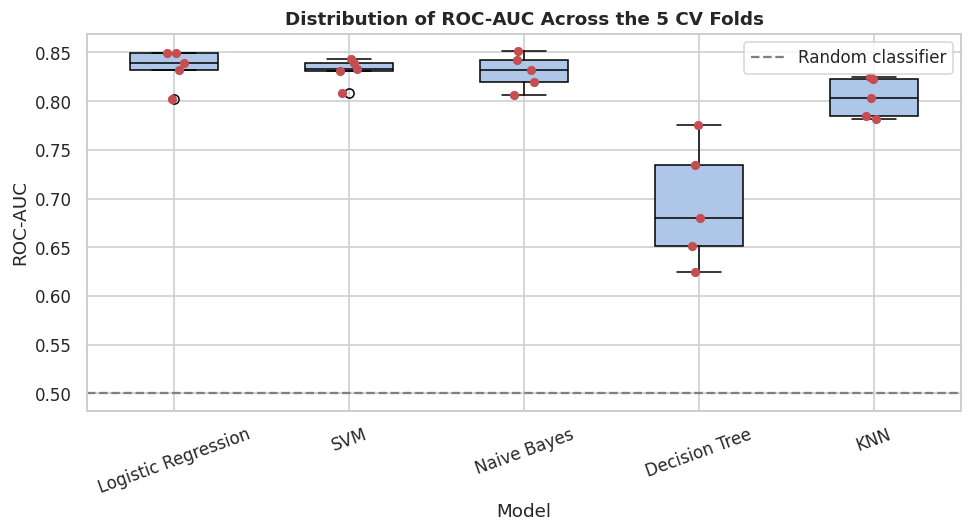

In [40]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot(auc_dist.values(), tick_labels=list(auc_dist.keys()), patch_artist=True,
           boxprops=dict(facecolor="#AEC7E8"), medianprops=dict(color="black"))
for i, vals in enumerate(auc_dist.values(), start=1):
    ax.scatter(np.full(len(vals), i) + np.random.uniform(-0.06, 0.06, len(vals)),
               vals, color="#C44E52", zorder=3, s=25)
ax.axhline(0.5, ls="--", c="grey", label="Random classifier")
ax.set_title("Distribution of ROC-AUC Across the 5 CV Folds")
ax.set_xlabel("Model")
ax.set_ylabel("ROC-AUC")
ax.tick_params(axis="x", rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

Cross validation confirms the ranking and adds nuance. Logistic Regression still leads on AUC 0.834 and F1 0.749, but **Naive Bayes is effectively tied** at 0.831 AUC and marginally higher accuracy 0.770 vs 0.767 with the tightest spread of all. On 400 patients that gap is well inside the noise, so the choice between them rests on interpretability rather than raw score.

The Decision Tree is both the weakest and by far the most variable. Its fold to fold standard deviation 0.055 AUC is roughly three times the linear models' 0.012 to 0.017. High variance is the defining failure mode of an unensembled tree and it is exactly why a Random Forest or gradient boosting, which average many trees to cancel that variance would be the natural next step if tree based methods were required.

Note also that every cross validated AUC is **higher** than its single split counterpart. Each CV model trains on more data and averaging over five folds removes the luck of one particular 80 patient test set. That is a good reminder of how much sampling noise a single split carries at this sample size.

## Bonus 3 Decision Tree feature importance

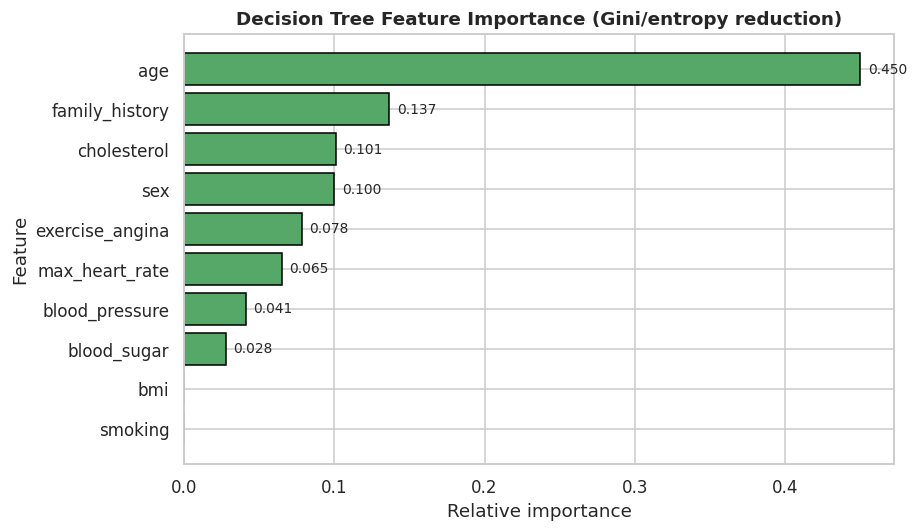

age                0.4499
family_history     0.1367
cholesterol        0.1009
sex                0.1001
exercise_angina    0.0784
max_heart_rate     0.0649
blood_pressure     0.0412
blood_sugar        0.0279
bmi                0.0000
smoking            0.0000


In [48]:
importances = pd.Series(dt_best.feature_importances_, index=feature_names)
importances = importances.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color="#55A868", edgecolor="black")
ax.set_title("Decision Tree Feature Importance (Gini/entropy reduction)")
ax.set_xlabel("Relative importance")
ax.set_ylabel("Feature")
for b, v in zip(bars, importances.values[::-1]):
    if v > 0:
        ax.text(v + 0.005, b.get_y() + b.get_height() / 2, f"{v:.3f}",
                va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(importances.round(4).to_string())

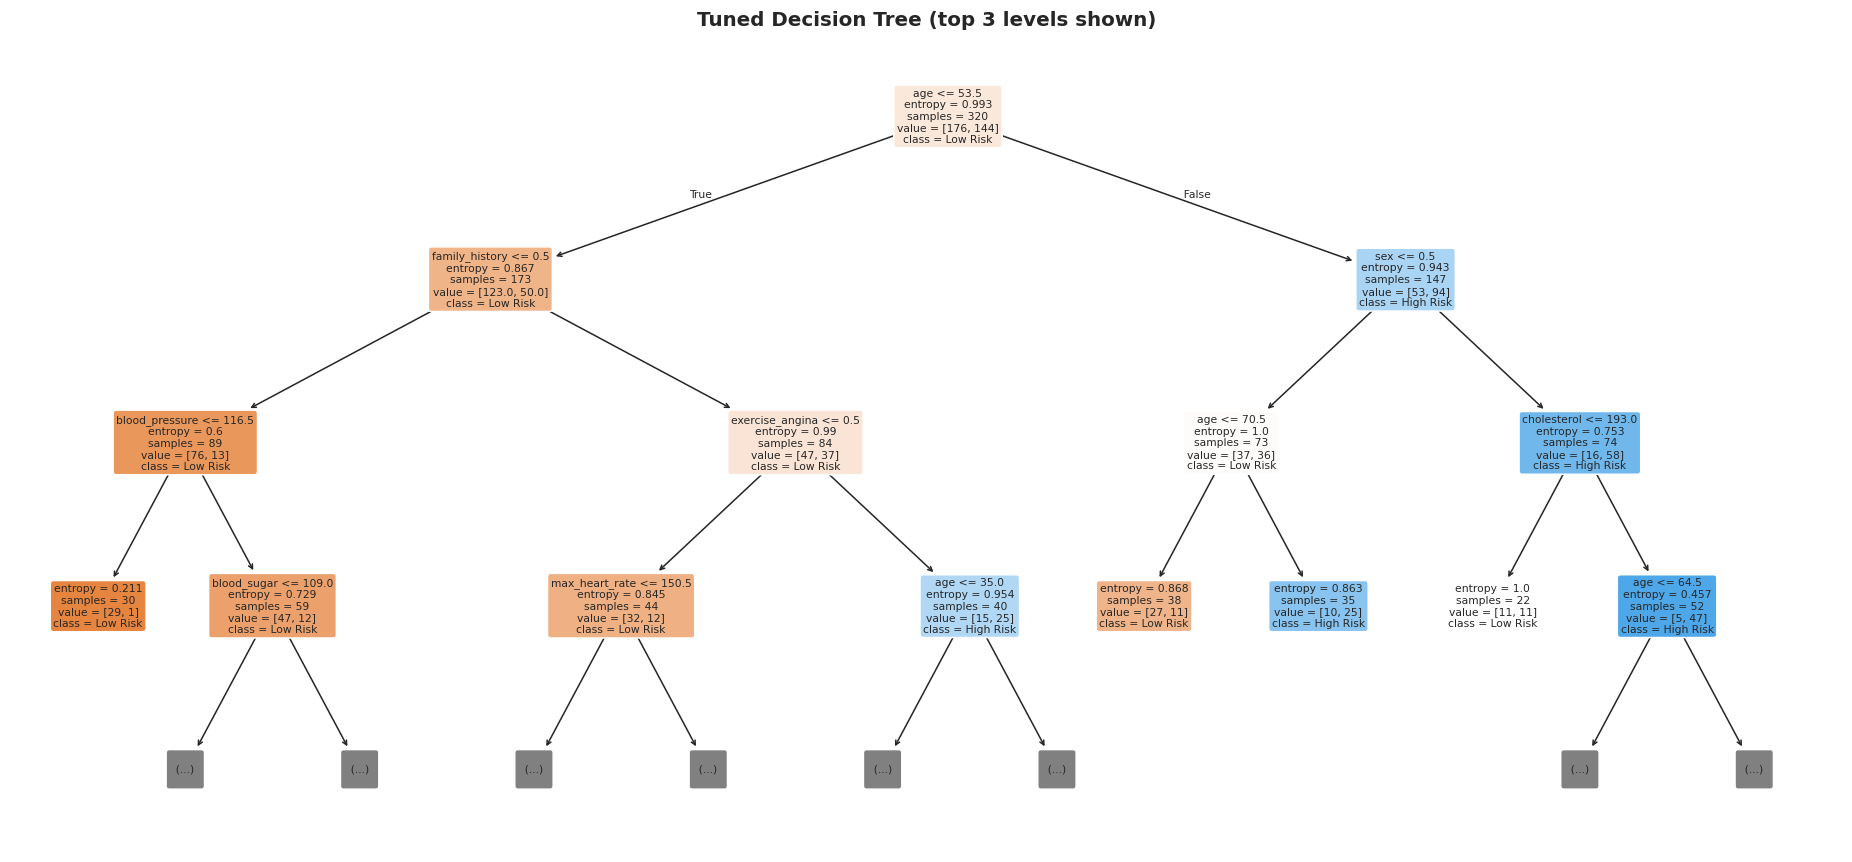

In [49]:
fig, ax = plt.subplots(figsize=(17, 8))
plot_tree(dt_best, feature_names=feature_names,
          class_names=["Low Risk", "High Risk"],
          filled=True, rounded=True, fontsize=7, max_depth=3, ax=ax)
ax.set_title("Tuned Decision Tree (top 3 levels shown)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Which features matter for disease risk?**

`age` dominates outright by approximation of 0.45 of the total and is the tree's root split, followed by `family_history`, `cholesterol` and `sex`, essentially the same ordering that the Logistic Regression coefficients and the correlation analysis produced. Three independent methods agreeing on the top features is a good sign that the signal is real rather than an artefact of one model.

Two cautions on reading tree importances. First `bmi` and `smoking` score **exactly zero**, but that does not mean they are irrelevant rather it means this particular tree never chose to split on them. Importance is winner takes all per split so marginal features get crowded out entirely and Logistic Regression still assigns `smoking` a non trivial coefficient. Second, importance is measured on the training set and inherits the tree's
high variance so a different random split can reshuffle the middle of this ranking substantially. Given the tree's poor test performance we treat this chart as a rough sanity check that corroborates the linear model, not as the authoritative feature ranking.

## Bonus 4 Decision threshold analysis

Previously I ahve stated that a screening tool should optimise recall. The default 0.5 cut off is an arbitrary convention and not a clinical decision. And because Logistic Regression outputs a calibrated probability the operating point can be moved without retraining.

In [43]:
probs = results["Logistic Regression"]["_score"]
thresholds = np.arange(0.10, 0.91, 0.05)

rows = []
for t in thresholds:
    pred = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred, labels=[0, 1]).ravel()
    rows.append({
        "Threshold": round(t, 2),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "Missed high-risk (FN)": fn,
        "False alarms (FP)": fp,
    })
thr = pd.DataFrame(rows)
print(thr.round(3).to_string(index=False))

 Threshold  Accuracy  Precision  Recall    F1  Missed high-risk (FN)  False alarms (FP)
      0.10     0.562      0.507   1.000 0.673                      0                 35
      0.15     0.588      0.522   0.972 0.680                      1                 32
      0.20     0.650      0.565   0.972 0.714                      1                 27
      0.25     0.650      0.571   0.889 0.696                      4                 24
      0.30     0.662      0.585   0.861 0.697                      5                 22
      0.35     0.725      0.646   0.861 0.738                      5                 17
      0.40     0.712      0.644   0.806 0.716                      7                 16
      0.45     0.712      0.644   0.806 0.716                      7                 16
      0.50     0.762      0.730   0.750 0.740                      9                 10
      0.55     0.725      0.733   0.611 0.667                     14                  8
      0.60     0.688      0.739 

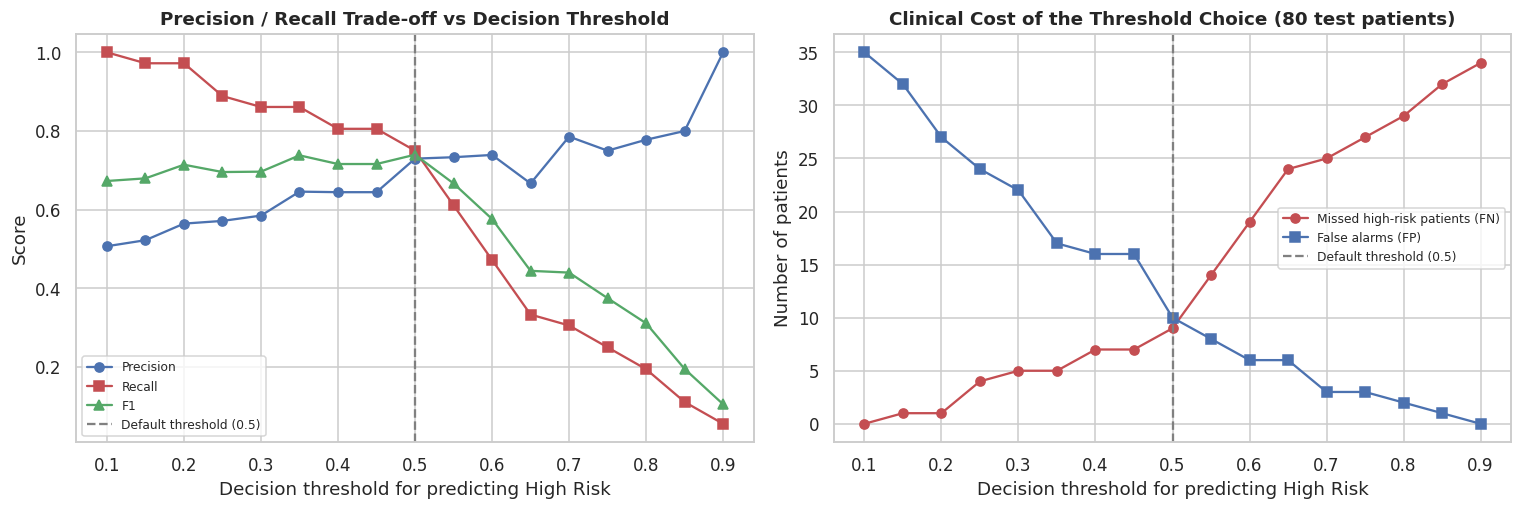

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

axes[0].plot(thr["Threshold"], thr["Precision"], "o-", label="Precision", color="#4C72B0")
axes[0].plot(thr["Threshold"], thr["Recall"], "s-", label="Recall", color="#C44E52")
axes[0].plot(thr["Threshold"], thr["F1"], "^-", label="F1", color="#55A868")
axes[0].axvline(0.5, ls="--", c="grey", label="Default threshold (0.5)")
axes[0].set_title("Precision / Recall Trade-off vs Decision Threshold")
axes[0].set_xlabel("Decision threshold for predicting High Risk")
axes[0].set_ylabel("Score")
axes[0].legend(fontsize=8)

axes[1].plot(thr["Threshold"], thr["Missed high-risk (FN)"], "o-",
             color="#C44E52", label="Missed high-risk patients (FN)")
axes[1].plot(thr["Threshold"], thr["False alarms (FP)"], "s-",
             color="#4C72B0", label="False alarms (FP)")
axes[1].axvline(0.5, ls="--", c="grey", label="Default threshold (0.5)")
axes[1].set_title("Clinical Cost of the Threshold Choice (80 test patients)")
axes[1].set_xlabel("Decision threshold for predicting High Risk")
axes[1].set_ylabel("Number of patients")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

In [45]:
target_recall = 0.90
ok = thr[thr["Recall"] >= target_recall]
if len(ok):
    best = ok.iloc[-1]
    print(f"Lowest threshold meeting recall >= {target_recall:.0%}: {best['Threshold']}")
    print(f"  Recall    : {best['Recall']:.3f}  ({int(best['Missed high-risk (FN)'])} high-risk patients missed)")
    print(f"  Precision : {best['Precision']:.3f}  ({int(best['False alarms (FP)'])} false alarms)")
    print(f"  Accuracy  : {best['Accuracy']:.3f}")
    print("\nTrade-off vs the default 0.5 threshold:")
    d = thr[thr["Threshold"] == 0.50].iloc[0]
    print(f"  Missed patients : {int(d['Missed high-risk (FN)'])} -> {int(best['Missed high-risk (FN)'])}")
    print(f"  False alarms    : {int(d['False alarms (FP)'])} -> {int(best['False alarms (FP)'])}")

Lowest threshold meeting recall >= 90%: 0.2
  Recall    : 0.972  (1 high-risk patients missed)
  Precision : 0.565  (27 false alarms)
  Accuracy  : 0.650

Trade-off vs the default 0.5 threshold:
  Missed patients : 9 -> 1
  False alarms    : 10 -> 27


This is the where recall argument is made concrete. Dropping the cut off from 0.50 to 0.20 takes the misses from **9 down to 1** while false alarms grow from 10 to 27. In a screening programme where a false alarm costs one follow up test and a miss can cost a life, that is plainly the right trade.

Note what happens to **accuracy** is that it falls from 0.762 to 0.650 as the model gets clinically more useful. That is the clearest possible illustration of why accuracy is the wrong thing to optimise here rather the metric that needs improvement.

---
# Final Summary

| | |
|---|---|
| **Best overall** | Logistic Regression: accuracy 0.763, F1 0.740, ROC-AUC 0.787 (CV AUC 0.834 +/- 0.017) |
| **Closest rivals** | Linear SVM (AUC 0.785) and Naive Bayes (CV AUC 0.831), statistically indistinguishable |
| **Worst** | Decision Tree: 100% training accuracy, test AUC 0.565, highest CV variance |
| **Most predictive features** | `age` clearly first, then `family_history`, `exercise_angina`, `sex`, `cholesterol` |
| **Metric to optimise** | Recall, because a missed high-risk patient is far costlier than a false alarm |
| **Recommended for production** | Logistic Regression, with the threshold tuned to the clinical recall target |

**Honest take on this project.** 400 patients is a small dataset and the test set is only 80 rows, so individual metrics carry a margin of roughly 5 percentage points which is exactly why the cross validated results in Bonus Section 2 should be trusted over the single split table. A ceiling of
AUC ≈ 0.79 single split to 0.83 cross validated means the features available here explain a good part of disease risk but far from all of it. This is a triage aid and not a diagnosis. Natural next steps ensemble methods Random Forest, gradient boosting could be used to fix the tree's variance problem, calibration curves to verify the probabilities are trustworthy, and
engineered interaction terms for example like age versus family history to give the linear models access to non additive effects.